# LSTM Model

## Import Libraries

In [1]:
import json
import os

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torch.utils.data import DataLoader, TensorDataset

## Parameters

In [2]:
DATASET_NAME = "vcb_lb20_h5_f200_dynta_tr70_val15_test15_std"
DATA_DIR = os.path.join("../../train_test_set", DATASET_NAME)

# --- input handling ---
CLIP_VALUE = 10.0       # clip scaled inputs to [-CLIP, CLIP] (tame distribution-shift outliers)
USE_TOP_FEATURES = 40   # subset to top-N features by blended importance (None = all)

# --- model (shrunk + regularized to fight overfitting) ---
HIDDEN_SIZE = 48
NUM_LAYERS = 1
DROPOUT = 0.4

# --- training ---
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 100
PATIENCE = 12           # early-stopping patience on val loss
GRAD_CLIP = 1.0
RANDOM_STATE = 42

L.seed_everything(RANDOM_STATE, workers=True)

Seed set to 42


42

## Load Data

In [3]:
def load(name):
    return np.load(os.path.join(DATA_DIR, name))

X_train, y_train = load("X_train.npy"), load("y_train.npy")
X_val, y_val = load("X_val.npy"), load("y_val.npy")
X_test, y_test = load("X_test.npy"), load("y_test.npy")

with open(os.path.join(DATA_DIR, "metadata.json")) as f:
    metadata = json.load(f)
target_scaler = joblib.load(os.path.join(DATA_DIR, "target_scaler.pkl"))

# Optionally subset to the most important features (by blended_score) to reduce overfitting
if USE_TOP_FEATURES:
    feat_cols = metadata["feature_columns"]
    ranking = pd.read_csv(os.path.join(DATA_DIR, "feature_ranking.csv"))
    ranked = ranking[ranking["feature"].isin(feat_cols)].sort_values("blended_score", ascending=False)
    top = ranked["feature"].head(USE_TOP_FEATURES).tolist()
    idx = [feat_cols.index(c) for c in top]
    X_train, X_val, X_test = X_train[:, :, idx], X_val[:, :, idx], X_test[:, :, idx]
    print(f"Subset to top {len(idx)} features by blended_score")

N_FEATURES = X_train.shape[-1]
print(f"X_train {X_train.shape}  X_val {X_val.shape}  X_test {X_test.shape}")
print(f"lookback={metadata['lookback_day']}  features={N_FEATURES}  horizon={metadata['target_horizon']}")

Subset to top 40 features by blended_score
X_train (2926, 20, 40)  X_val (631, 20, 40)  X_test (632, 20, 40)
lookback=20  features=40  horizon=5


## DataModule

In [4]:
class StockDataModule(L.LightningDataModule):
    """Wraps the pre-windowed npy tensors; clips scaled inputs to tame outliers."""

    def __init__(self, splits, batch_size, clip_value):
        super().__init__()
        self.splits = splits
        self.batch_size = batch_size
        self.clip_value = clip_value

    def _ds(self, key):
        X, y = self.splits[key]
        X = np.clip(X, -self.clip_value, self.clip_value)
        return TensorDataset(
            torch.from_numpy(X).float(),
            torch.from_numpy(y).float().unsqueeze(-1),
        )

    def setup(self, stage=None):
        self.train_ds = self._ds("train")
        self.val_ds = self._ds("val")
        self.test_ds = self._ds("test")

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False)


splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
datamodule = StockDataModule(splits, BATCH_SIZE, CLIP_VALUE)

## Model

In [5]:
class LSTMRegressor(L.LightningModule):
    """Bidirectional LSTM + attention pooling over timesteps -> linear head -> scalar.

    The 20-day window is entirely historical, so bidirectional encoding is leak-free.
    Attention pools all timesteps (learned weights) instead of using only the last state.
    Huber (SmoothL1) loss is robust to fat-tailed big-move returns.
    """

    def __init__(self, num_features, hidden_size, num_layers, dropout, lr, weight_decay):
        super().__init__()
        self.save_hyperparameters()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        d = hidden_size * 2  # bidirectional
        self.attn = nn.Linear(d, 1)
        self.head = nn.Sequential(
            nn.Linear(d, d // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d // 2, 1),
        )
        self.criterion = nn.SmoothL1Loss(beta=1.0)

    def forward(self, x):
        out, _ = self.lstm(x)                      # (B, T, 2H)
        w = torch.softmax(self.attn(out), dim=1)   # (B, T, 1) attention over timesteps
        ctx = (w * out).sum(dim=1)                 # (B, 2H) pooled context
        return self.head(ctx)

    def _step(self, batch, stage):
        x, y = batch
        loss = self.criterion(self(x), y)
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, "train")

    def validation_step(self, batch, _):
        return self._step(batch, "val")

    def test_step(self, batch, _):
        return self._step(batch, "test")

    def predict_step(self, batch, _):
        x, _y = batch
        return self(x)

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "val_loss"}}


model = LSTMRegressor(N_FEATURES, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, LEARNING_RATE, WEIGHT_DECAY)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMRegressor(
  (lstm): LSTM(40, 48, batch_first=True, bidirectional=True)
  (attn): Linear(in_features=96, out_features=1, bias=True)
  (head): Sequential(
    (0): Linear(in_features=96, out_features=48, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=48, out_features=1, bias=True)
  )
  (criterion): SmoothL1Loss()
)
Trainable parameters: 39,362


## Train

In [6]:
early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=PATIENCE)
checkpoint = ModelCheckpoint(
    dirpath="checkpoints",
    filename=f"lstm_{DATASET_NAME}",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)
logger = CSVLogger(save_dir=".", name="lightning_logs")

trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    devices=1,
    gradient_clip_val=GRAD_CLIP,
    callbacks=[early_stop, checkpoint],
    logger=logger,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

trainer.fit(model, datamodule=datamodule)
print(f"Best val_loss = {checkpoint.best_model_score:.4f}")
print(f"Best checkpoint: {checkpoint.best_model_path}")

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


D:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory D:\GIT\master-thesis\src\model\lstm\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Validation DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 138.37it/s]

Epoch 12: 100%|██████████| 46/46 [00:00<00:00, 79.99it/s, v_num=4, val_loss=0.669, train_loss=0.198]

Epoch 12: 100%|██████████| 46/46 [00:00<00:00, 79.78it/s, v_num=4, val_loss=0.669, train_loss=0.187]

Epoch 12: 100%|██████████| 46/46 [00:00<00:00, 79.01it/s, v_num=4, val_loss=0.669, train_loss=0.187]


Best val_loss = 0.2748
Best checkpoint: D:\GIT\master-thesis\src\model\lstm\checkpoints\lstm_vcb_lb20_h5_f200_dynta_tr70_val15_test15_std-v4.ckpt


## Evaluate

In [7]:
# Load best checkpoint and evaluate
best_model = LSTMRegressor.load_from_checkpoint(checkpoint.best_model_path)
trainer.test(best_model, datamodule=datamodule)


def report(name, X, y):
    Xc = np.clip(X, -CLIP_VALUE, CLIP_VALUE)
    preds = trainer.predict(
        best_model,
        DataLoader(TensorDataset(torch.from_numpy(Xc).float(),
                                 torch.from_numpy(y).float().unsqueeze(-1)),
                   batch_size=BATCH_SIZE),
    )
    p_scaled = torch.cat(preds).numpy().ravel()
    # inverse-transform to real pct-return units
    p = target_scaler.inverse_transform(p_scaled.reshape(-1, 1)).ravel()
    t = target_scaler.inverse_transform(y.reshape(-1, 1)).ravel()
    rmse = float(np.sqrt(np.mean((p - t) ** 2)))
    mae = float(np.mean(np.abs(p - t)))
    # R^2: 1 - SS_res/SS_tot vs predicting this split's mean; can be negative out-of-sample
    ss_res = float(np.sum((t - p) ** 2))
    ss_tot = float(np.sum((t - t.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    dir_acc = float(np.mean(np.sign(p) == np.sign(t)))
    corr = float(np.corrcoef(p, t)[0, 1])
    print(f"{name:5s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  dir_acc={dir_acc:.3f}  corr={corr:.3f}")
    return p, t


print()
print("(real pct-return units, target inverse-transformed)")
report("train", X_train, y_train)
report("val", X_val, y_val)
test_pred, test_true = report("test", X_test, y_test)

D:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


D:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

Testing DataLoader 0:   0%|          | 0/10 [00:00<?, ?it/s]

...

Predicting DataLoader 0:  80%|████████  | 8/10 [00:00<00:00, 240.04it/s]

Predicting DataLoader 0:  90%|█████████ | 9/10 [00:00<00:00, 247.68it/s]

Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 250.89it/s]

Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 238.91it/s]


test   RMSE=3.6043  MAE=2.2536  R2=-0.0122  dir_acc=0.464  corr=0.058


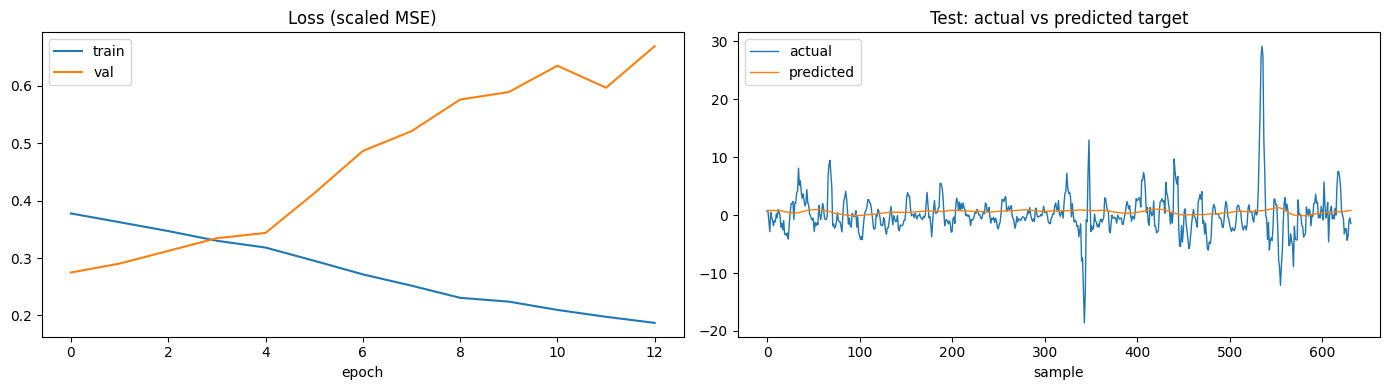

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Loss curves from the CSV logger
metrics = pd.read_csv(os.path.join(logger.log_dir, "metrics.csv"))
train_curve = metrics.dropna(subset=["train_loss"]).groupby("epoch")["train_loss"].last()
val_curve = metrics.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].last()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(train_curve.index, train_curve.values, label="train")
ax[0].plot(val_curve.index, val_curve.values, label="val")
ax[0].set_title("Loss (scaled MSE)")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(test_true, label="actual", linewidth=1)
ax[1].plot(test_pred, label="predicted", linewidth=1)
ax[1].set_title("Test: actual vs predicted target")
ax[1].set_xlabel("sample")
ax[1].legend()
fig.tight_layout()
plt.show()

## Save Model

In [9]:
# Lightning already saved the best checkpoint via ModelCheckpoint.
print(f"Best checkpoint: {checkpoint.best_model_path}")
print(f"Best val_loss:   {float(checkpoint.best_model_score):.4f}")
print(f"CSV logs:        {logger.log_dir}")

Best checkpoint: D:\GIT\master-thesis\src\model\lstm\checkpoints\lstm_vcb_lb20_h5_f200_dynta_tr70_val15_test15_std-v4.ckpt
Best val_loss:   0.2748
CSV logs:        .\lightning_logs\version_4
